In [1]:
import torch
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Assuming that we are on a CUDA machine, this should print a CUDA device:

print(device)

cuda:0


# **ResNet50**

Files already downloaded and verified
Files already downloaded and verified

Report for epoch: 1
valid accuracy: 60.5000, valid loss: 39.5000
train accuracy: 61.3867, train loss: 38.6133


Report for epoch: 2
valid accuracy: 63.6800, valid loss: 36.3200
train accuracy: 65.5244, train loss: 34.4756


Report for epoch: 3
valid accuracy: 69.5000, valid loss: 30.5000
train accuracy: 73.1778, train loss: 26.8222


Report for epoch: 4
valid accuracy: 73.3400, valid loss: 26.6600
train accuracy: 77.3244, train loss: 22.6756


Report for epoch: 5
valid accuracy: 68.6000, valid loss: 31.4000
train accuracy: 72.3267, train loss: 27.6733


Report for epoch: 6
valid accuracy: 75.6000, valid loss: 24.4000
train accuracy: 82.3933, train loss: 17.6067


Report for epoch: 7
valid accuracy: 78.5000, valid loss: 21.5000
train accuracy: 85.3933, train loss: 14.6067


Report for epoch: 8
valid accuracy: 77.6800, valid loss: 22.3200
train accuracy: 84.8333, train loss: 15.1667


Report for epoch: 9
valid a

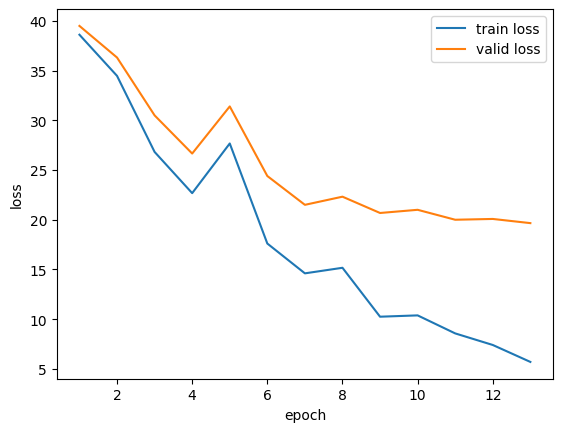

In [4]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import time

model_name = 'ResNet50'

# Load CIFAR-10 dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # نرمال سازی
])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Split trainset into train and validation sets
trainset, validset = random_split(trainset, [45000, 5000])

# Create data loaders
batch_size = 32
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
validloader = DataLoader(validset, batch_size=batch_size, shuffle=False, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

# Define ResNet50 model with modifications
import torchvision.models as models

resnet50 = models.resnet50(pretrained=True)

# Freeze the pre-trained layers
for param in resnet50.parameters():
    param.requires_grad = False

# Modify the classifier
num_features = resnet50.fc.in_features
resnet50.fc = nn.Sequential(
    nn.Linear(num_features, 1024),
    nn.ReLU(inplace=True),
    nn.Linear(1024, 512),
    nn.ReLU(inplace=True),
    nn.Linear(512, 256),
    nn.ReLU(inplace=True),
    nn.Linear(256, 10)  # 10 classes in CIFAR-10
)


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
resnet50 = resnet50.to(device)

# Define criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet50.parameters(), lr=0.001)

# calculate accuracy
def accuracy(loader):
    correct = 0
    total = 0
    with torch.no_grad():
        for data in loader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = resnet50(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return (100 * correct / total)

# Training
epoch = 0
stop_condition = False

accuracy_list_valid=[]
error_list_train_plot=[]
error_list_valid_plot=[]

start_time = time.time()
while (epoch < 20 and not stop_condition):
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet50(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    epoch += 1

    accuracy_train = accuracy(trainloader)
    accuracy_valid = accuracy(validloader)
    print(f'\nReport for epoch: {epoch}')
    print(f'valid accuracy: {accuracy_valid:.4f}, valid loss: {100-accuracy_valid:.4f}')
    print(f'train accuracy: {accuracy_train:.4f}, train loss: {100-accuracy_train:.4f}\n')

    error_list_valid_plot.append(100-accuracy_valid)
    error_list_train_plot.append(100-accuracy_train)
    accuracy_list_valid.append(accuracy_valid)

    #check stop condition
    last_3_acc = accuracy_list_valid[-3:]
    if max(last_3_acc) - sum(last_3_acc) / 3 <= 0.3:
        stop_condition = True

end_time = time.time()

#Report generating
avg_epoch_runtime=(end_time-start_time)/epoch

print("================================\n")
print(f"(Training finished in {epoch} epochs)")
print(f"Average epoch's runtime: {avg_epoch_runtime} seconds")
print(f'accuracy on test data: {accuracy(testloader):.4f}, loss of test data: {100-accuracy(testloader):.4f}\n\n')



# Save the model
torch.save(resnet50.state_dict(), 'resnet50_cifar10.pth')

import os

if (os.path.exists('/content/drive/MyDrive/model')==False):
  os.mkdir('/content/drive/MyDrive/model')
PATH = '/content/drive/MyDrive/model/'+model_name+'.pth'
torch.save(resnet50.state_dict(), PATH)



dataiter = iter(testloader)
images, labels = next(dataiter)



#load model
net = resnet50
net.load_state_dict(torch.load(PATH))


#Drawing plot
import numpy as np
import matplotlib.pyplot as plt

x=list(range(1,len(error_list_train_plot)+1))

x=np.array(x)
y_train=np.array(error_list_train_plot)
y_valid=np.array(error_list_valid_plot)

plt.plot(x,y_train)
plt.plot(x,y_valid)
plt.xlabel("epoch")
plt.ylabel('loss')
plt.legend(['train loss', 'valid loss'])
plt.savefig('/content/drive/MyDrive/model/'+model_name+'.png')
plt.show()